In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [23]:
df = pd.read_csv('data/ibm_hr_attrition.csv')
print('Размер датасета:', df.shape)
df.head()

Размер датасета: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [24]:
print('Пропущенные значения:', df.isnull().sum().sum())
print()
print('Распределение по отделам:')
print(df['Department'].value_counts())
print()
print('Распределение по должностям:')
print(df['JobRole'].value_counts())
print()
print('Распределение по полу:')
print(df['Gender'].value_counts())

Пропущенные значения: 0

Распределение по отделам:
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

Распределение по должностям:
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

Распределение по полу:
Gender
Male      882
Female    588
Name: count, dtype: int64


In [25]:
attrition_counts = df['Attrition'].value_counts()
attrition_share = df['Attrition'].value_counts(normalize=True) * 100

print('Абсолютные значения:')
print(attrition_counts)
print()
print('Доли в процентах:')
print(attrition_share.round(2))

Абсолютные значения:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Доли в процентах:
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


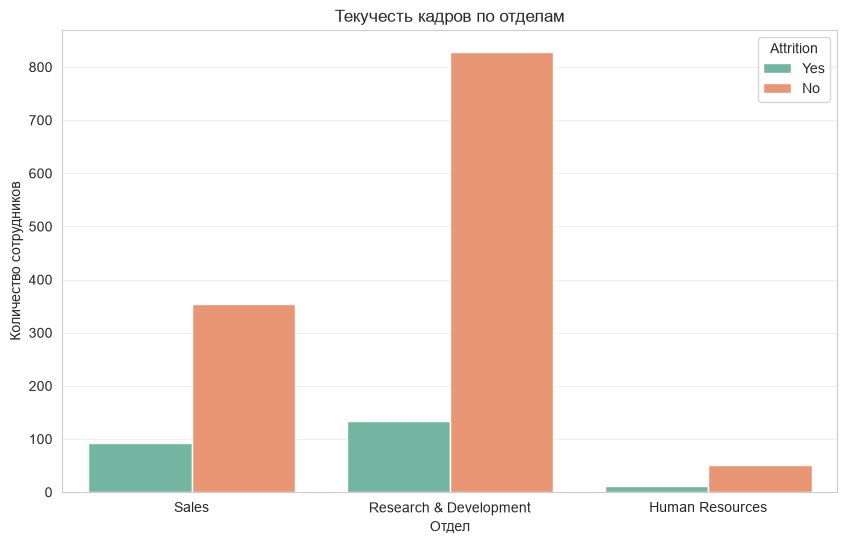

Доля уволившихся внутри каждого отдела:
Attrition                  No    Yes
Department                          
Human Resources         80.95  19.05
Research & Development  86.16  13.84
Sales                   79.37  20.63


In [26]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Department', hue='Attrition', palette='Set2')
plt.title('Текучесть кадров по отделам')
plt.xlabel('Отдел')
plt.ylabel('Количество сотрудников')
plt.grid(alpha=0.3, axis='y')
plt.savefig('docs/hr_attrition_by_department.png', dpi=200, bbox_inches='tight')
plt.show()

attrition_by_dept = pd.crosstab(df['Department'], df['Attrition'], normalize='index') * 100
print('Доля уволившихся внутри каждого отдела:')
print(attrition_by_dept.round(2))

C:\Users\Acer\AppData\Local\Temp\ipykernel_18152\3887645593.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attrition_by_role['Yes'], y=attrition_by_role.index, palette='Reds_r')


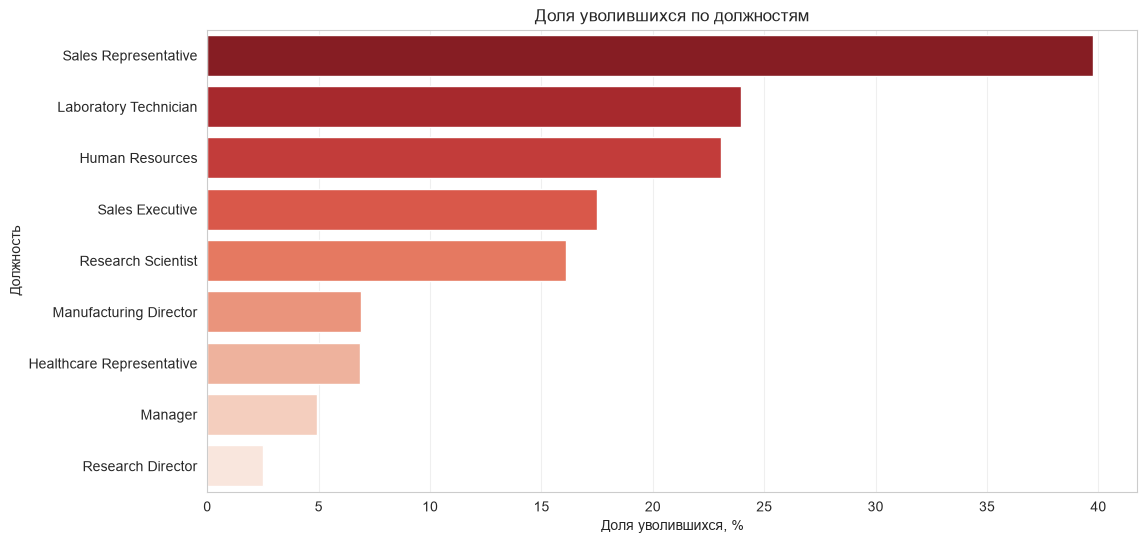

In [27]:
plt.figure(figsize=(12, 6))
attrition_by_role = pd.crosstab(df['JobRole'], df['Attrition'], normalize='index') * 100
attrition_by_role = attrition_by_role.sort_values('Yes', ascending=False)
sns.barplot(x=attrition_by_role['Yes'], y=attrition_by_role.index, palette='Reds_r')
plt.title('Доля уволившихся по должностям')
plt.xlabel('Доля уволившихся, %')
plt.ylabel('Должность')
plt.grid(alpha=0.3, axis='x')
plt.savefig('docs/hr_attrition_by_role.png', dpi=200, bbox_inches='tight')
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_18152\494298349.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='Age', ax=axes[0], palette='Set2')
C:\Users\Acer\AppData\Local\Temp\ipykernel_18152\494298349.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[1], palette='Set2')


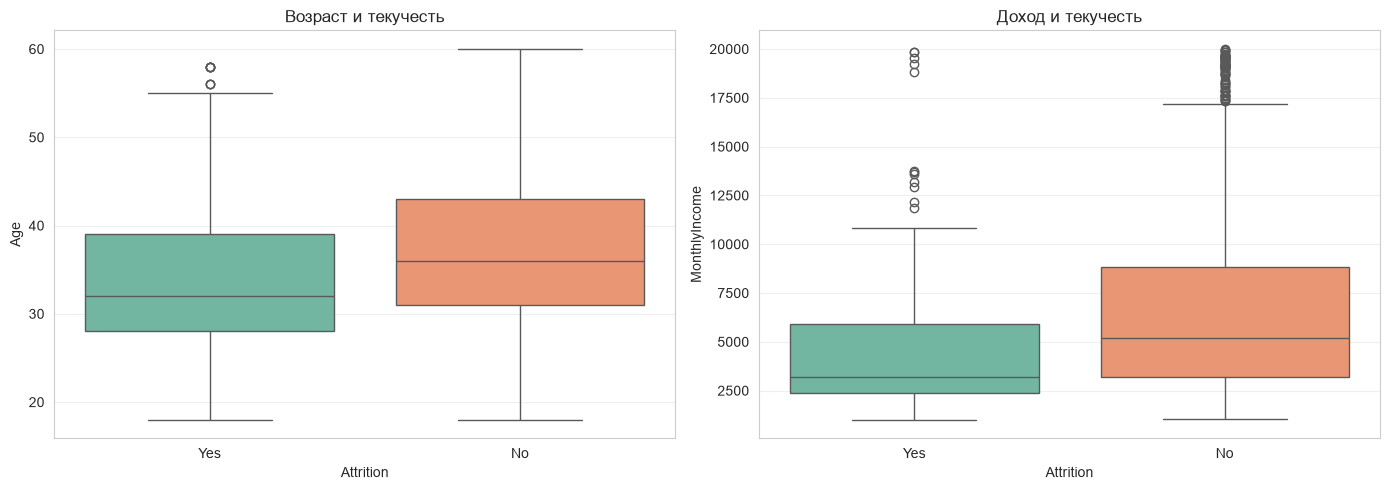

Средний возраст уволившихся: 33.61
Средний возраст оставшихся: 37.56

Средний доход уволившихся: 4787.09
Средний доход оставшихся: 6832.74


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Attrition', y='Age', ax=axes[0], palette='Set2')
axes[0].set_title('Возраст и текучесть')
axes[0].grid(alpha=0.3, axis='y')

sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[1], palette='Set2')
axes[1].set_title('Доход и текучесть')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('docs/hr_age_income.png', dpi=200, bbox_inches='tight')
plt.show()

print('Средний возраст уволившихся:', df[df['Attrition'] == 'Yes']['Age'].mean().round(2))
print('Средний возраст оставшихся:', df[df['Attrition'] == 'No']['Age'].mean().round(2))
print()
print('Средний доход уволившихся:', df[df['Attrition'] == 'Yes']['MonthlyIncome'].mean().round(2))
print('Средний доход оставшихся:', df[df['Attrition'] == 'No']['MonthlyIncome'].mean().round(2))

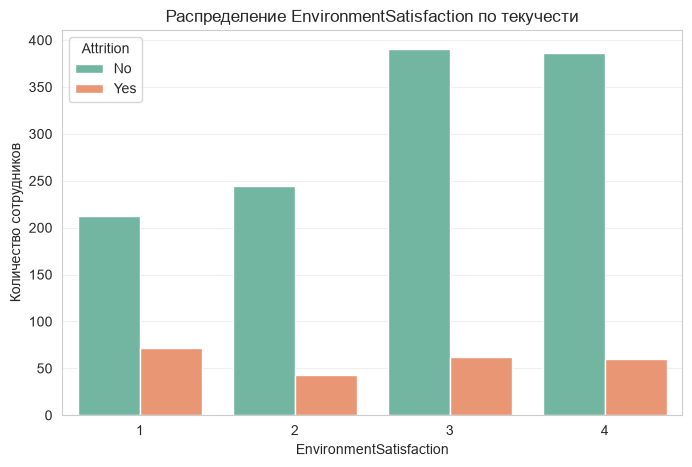

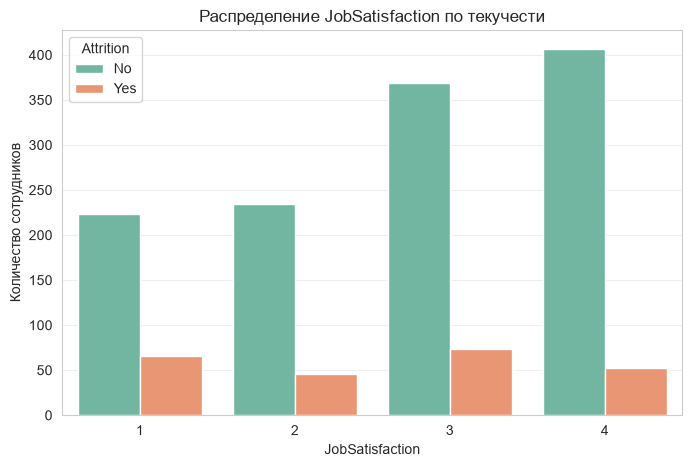

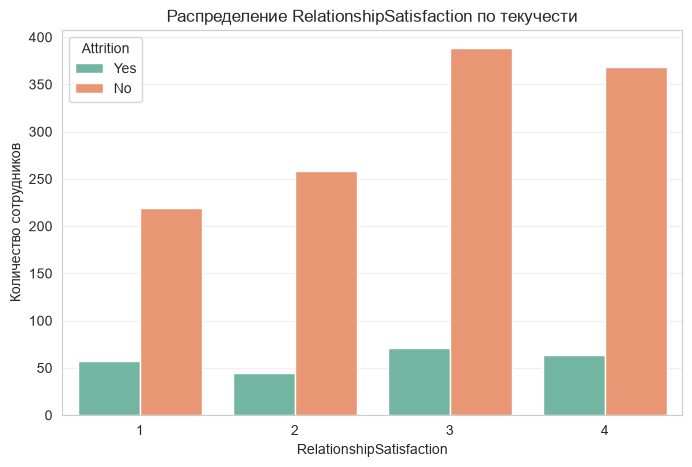

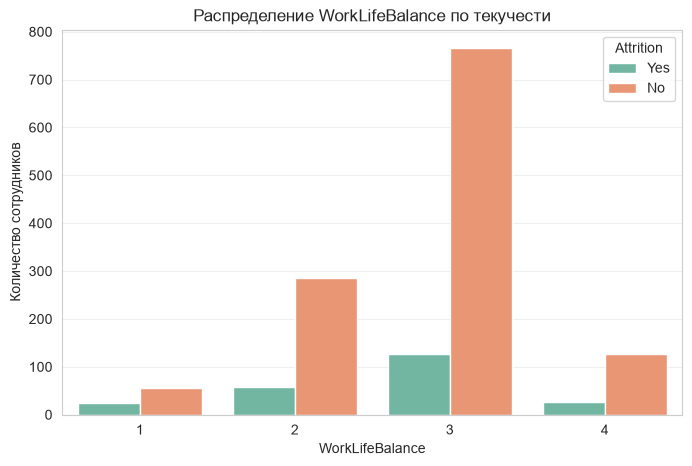

In [29]:
satisfaction_cols = ['EnvironmentSatisfaction', 'JobSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance']

for col in satisfaction_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=col, hue='Attrition', palette='Set2')
    plt.title(f'Распределение {col} по текучести')
    plt.xlabel(col)
    plt.ylabel('Количество сотрудников')
    plt.grid(alpha=0.3, axis='y')
    plt.show()

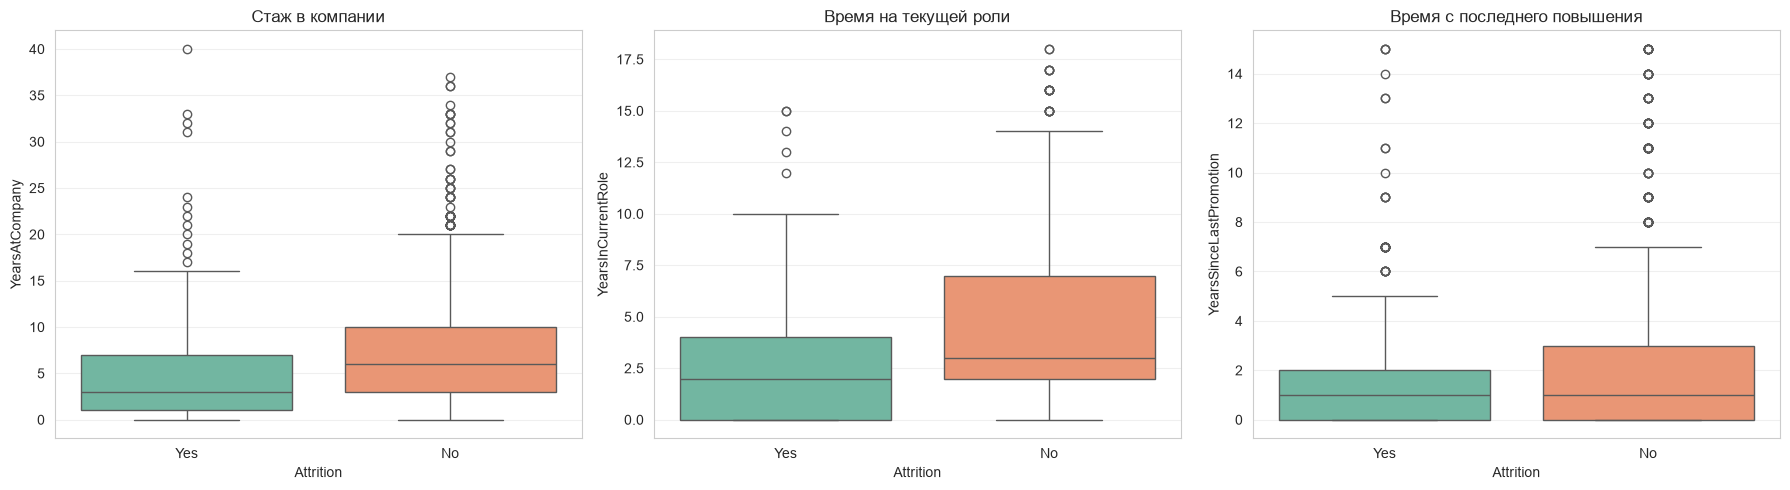

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='Attrition', y='YearsAtCompany', ax=axes[0], hue='Attrition', palette='Set2', legend=False)
axes[0].set_title('Стаж в компании')
axes[0].grid(alpha=0.3, axis='y')

sns.boxplot(data=df, x='Attrition', y='YearsInCurrentRole', ax=axes[1], hue='Attrition', palette='Set2', legend=False)
axes[1].set_title('Время на текущей роли')
axes[1].grid(alpha=0.3, axis='y')

sns.boxplot(data=df, x='Attrition', y='YearsSinceLastPromotion', ax=axes[2], hue='Attrition', palette='Set2', legend=False)
axes[2].set_title('Время с последнего повышения')
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('docs/hr_tenure.png', dpi=200, bbox_inches='tight')
plt.show()

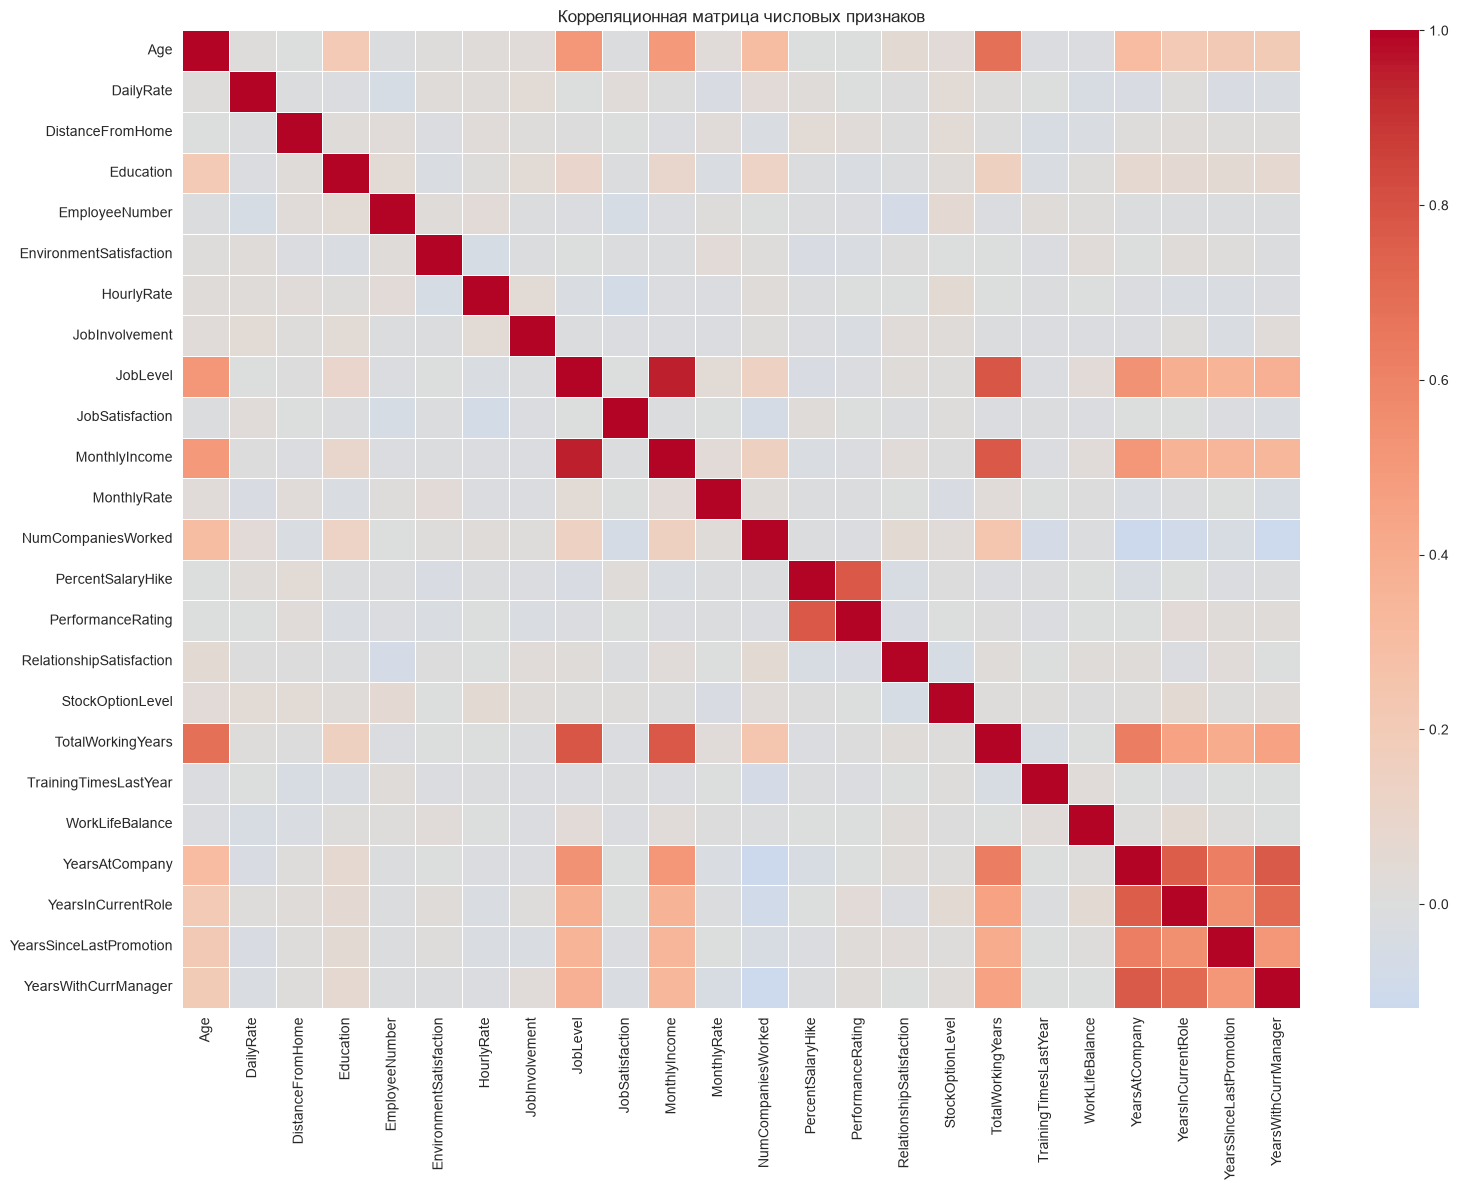

In [31]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = [col for col in numeric_cols if df[col].nunique() > 1]
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.savefig('docs/hr_correlation.png', dpi=200, bbox_inches='tight')
plt.show()

In [32]:
df['Attrition_binary'] = (df['Attrition'] == 'Yes').astype(int)
attrition_corr = df[numeric_cols].corrwith(df['Attrition_binary']).sort_values()

print('Корреляция числовых признаков с фактом увольнения:')
print(attrition_corr.round(3))

Корреляция числовых признаков с фактом увольнения:
TotalWorkingYears          -0.171
JobLevel                   -0.169
YearsInCurrentRole         -0.161
MonthlyIncome              -0.160
Age                        -0.159
YearsWithCurrManager       -0.156
StockOptionLevel           -0.137
YearsAtCompany             -0.134
JobInvolvement             -0.130
JobSatisfaction            -0.103
EnvironmentSatisfaction    -0.103
WorkLifeBalance            -0.064
TrainingTimesLastYear      -0.059
DailyRate                  -0.057
RelationshipSatisfaction   -0.046
YearsSinceLastPromotion    -0.033
Education                  -0.031
PercentSalaryHike          -0.013
EmployeeNumber             -0.011
HourlyRate                 -0.007
PerformanceRating           0.003
MonthlyRate                 0.015
NumCompaniesWorked          0.043
DistanceFromHome            0.078
dtype: float64


Доля уволившихся в зависимости от сверхурочной работы:
Attrition     No    Yes
OverTime               
No         89.56  10.44
Yes        69.47  30.53


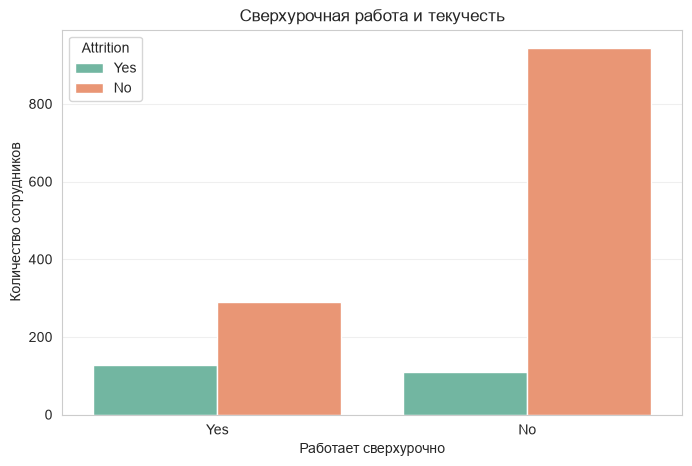

In [33]:
overtime_attrition = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
print('Доля уволившихся в зависимости от сверхурочной работы:')
print(overtime_attrition.round(2))

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='OverTime', hue='Attrition', palette='Set2')
plt.title('Сверхурочная работа и текучесть')
plt.xlabel('Работает сверхурочно')
plt.ylabel('Количество сотрудников')
plt.grid(alpha=0.3, axis='y')
plt.savefig('docs/hr_overtime.png', dpi=200, bbox_inches='tight')
plt.show()

In [34]:
print('Итоговые показатели по датасету:')
print(f'Всего сотрудников: {len(df)}')
print(f'Уволилось: {(df["Attrition"] == "Yes").sum()} ({(df["Attrition"] == "Yes").mean() * 100:.1f}%)')
print(f'Средний возраст: {df["Age"].mean():.1f}')
print(f'Средний доход: {df["MonthlyIncome"].mean():.0f}')
print(f'Средний стаж в компании: {df["YearsAtCompany"].mean():.1f}')
print()
print('Доля уволившихся по должностям (топ-5):')
print(attrition_by_role['Yes'].head().round(2))

Итоговые показатели по датасету:
Всего сотрудников: 1470
Уволилось: 237 (16.1%)
Средний возраст: 36.9
Средний доход: 6503
Средний стаж в компании: 7.0

Доля уволившихся по должностям (топ-5):
JobRole
Sales Representative     39.76
Laboratory Technician    23.94
Human Resources          23.08
Sales Executive          17.48
Research Scientist       16.10
Name: Yes, dtype: float64
